<a href="https://colab.research.google.com/github/JuanZapa7a/AINavalEngineering/blob/main/Prac_11_A_Machine_Learning_Project_in_Python_Step-By-Step.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: A Machine Learning Project in Python Step-By-Step

We need to see how all of the pieces of a predictive modeling machine learning project actually
fit together. In this lesson you will complete your first machine learning project using Python.
In this step-by-step tutorial project you will:
- Download and install Python SciPy and get the most useful package for machine learning
in Python.
- Load a dataset and understand it’s structure using statistical summaries and data visual-
ization.
- Create 6 machine learning models, pick the best and build confidence that the accuracy is
reliable.

## The Hello World of Machine Learning

The best small project to start with on a new tool is the classification of naval dataset. This is a
good dataset for your first project because it is so well understood.
- Attributes are numeric so you have to figure out how to load and handle data.
- It is a classification problem, allowing you to practice with an easier type of supervised
learning algorithm.
- It is a multiclass classification problem (multi-nominal) that may require some specialized
handling.
- It only has 4 attributes and 150 rows, meaning it is small and easily fits into memory (and
a screen or single sheet of paper).
- All of the numeric attributes are in the same units and the same scale not requiring any
special scaling or transforms to get started.

We are going to work through a small machine learning project end-to-end.
Here is an overview of what we are going to cover:
1. Loading the dataset.
2. Summarizing the dataset.
3. Visualizing the dataset.
4. Evaluating some algorithms.
5. Making some predictions.

Take your time and work through each step. Try to type in the commands yourself or
copy-and-paste the commands to speed things up. Start your Python interactive environment
and let’s get started with your hello world machine learning project in Python.

## Load The Data
In this step we are going to load the libraries and the naval data CSV file from URL.

---
**Load libraries**

---

In [ ]:
# Load libraries
from pandas import read_csv
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

Everything should load without error. If you have an error, stop. You need a working SciPy
environment before continuing.

---
**Load Dataset**

---

The the naval data CSV dataset file from URL can be downloaded. We are using
Pandas to load the data. We will also use Pandas next to explore the data both with descriptive statistics and data visualization. Note that we are specifying the names of each column when
loading the data. This will help later when we explore the data.

In [ ]:
!wget -O /content/sample_data/Naval_Dataset3.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset3.csv

--2025-04-03 08:25:25--  https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/Naval_Dataset3.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5714 (5.6K) [text/plain]
Saving to: ‘/content/sample_data/Naval_Dataset3.csv’

/content/sample_dat 100%[===================>]   5.58K  --.-KB/s    in 0s      

2025-04-03 08:25:25 (54.5 MB/s) - ‘/content/sample_data/Naval_Dataset3.csv’ saved [5714/5714]



In [ ]:
# Load the dataset
filename = '/content/sample_data/Naval_Dataset3.csv'
names = ['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']
data = read_csv(filename, names=names)
array = data.values

#### **Features (numerical columns)**
These are key dimensions of naval structures, such as:
1. **Length** (length of vessel)
2. **Beam** (width of vessel)
3. **Draft** (submerged depth)
4. **Block coefficient** (ratio of hull volume to enveloping parallelepiped)

#### **Classes (types of vessels or naval structures)**
Classes represent different types of vessels **Vessel Type** with different characteristics, such as:    
1. **Bulk Carrier**  
2. **Container Ship** (Buque de Pasajeros)  
3. **Offshore Vessel** (Buque Pesquero)  


## Summarize the Dataset


Now it is time to take a look at the data. In this step we are going to take a look at the data a
few different ways:
- Dimensions of the dataset.
- Peek at the data itself.
- Statistical summary of all attributes.
- Breakdown of the data by the class variable.





We can get a quick idea of how many instances (rows) and how many attributes (columns) the
data contains with the shape property.

---
**Data Shape**

---

In [ ]:
# shape
print(data.shape)

(150, 5)


You should see 150 instances and 5 attributes:

---
**Show first rows**

---

It is also always a good idea to actually eyeball your data.

In [ ]:
# head
print(data.head(20))

    Length (m)  Beam (m)  Draft (m)  Displacement (Tn)   Vessel Type
0        189.9      36.9       10.2            42354.0  Bulk Carrier
1        177.2      30.5       11.8            29593.0  Bulk Carrier
2        193.0      38.0       11.1            40028.0  Bulk Carrier
3        210.5      35.2       12.5            48928.0  Bulk Carrier
4        175.3      30.4        9.9            27326.0  Bulk Carrier
5        175.3      33.7       10.5            36287.0  Bulk Carrier
6        211.6      42.3       10.4            43916.0  Bulk Carrier
7        195.3      33.6        8.8            43279.0  Bulk Carrier
8        170.6      29.9       11.4            28237.0  Bulk Carrier
9        190.9      33.3       11.4            31868.0  Bulk Carrier
10       170.7      29.6       11.0            37056.0  Bulk Carrier
11       170.7      33.6       10.6            35922.0  Bulk Carrier
12       184.8      34.5        8.9            38520.0  Bulk Carrier
13       141.7      27.7       10.

---
**Statistical Summary**

---

Now we can take a look at a summary of each attribute. This includes the count, mean, the min and max values as well as some percentiles.

In [ ]:
# Statistical Summary
print(pd.DataFrame(data).describe())

       Length (m)    Beam (m)   Draft (m)  Displacement (Tn)
count  150.000000  150.000000  150.000000         150.000000
mean   166.189333   29.064000   10.084667       30843.066667
std     54.734647    6.445708    3.471470       12745.562511
min     60.000000   12.200000    4.000000       10000.000000
25%    124.850000   25.200000    7.025000       18870.250000
50%    172.800000   30.050000   10.650000       33071.000000
75%    205.700000   33.675000   12.700000       39777.750000
max    280.000000   42.600000   16.000000       62603.000000


We can see that all of the numerical values have the same scale (m) and similar
ranges.

---
**Class Distribution**

---

Let’s now take a look at the number of instances (rows) that belong to each class. We can view
this as an absolute count.

In [ ]:
# class distribution
print(pd.DataFrame(data, columns=['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']).groupby('Vessel Type').size()) # Changed 'class' to 'Vessel Type' as this is the actual column name from read_csv

Vessel Type
Bulk Carrier       50
Container Ship     50
Offshore Vessel    50
dtype: int64


We can see that each class has the same number of instances (50 or 33% of the dataset).


## Data Visualization

We now have a basic idea about the data. We need to extend this with some visualizations. We
are going to look at two types of plots:
- Univariate plots to better understand each attribute.
- Multivariate plots to better understand the relationships between attributes.


---
**Univariate Plots: whisker plot**

---

We will start with some univariate plots, that is, plots of each individual variable. Given that
the input variables are numeric, we can create box and whisker plots of each.

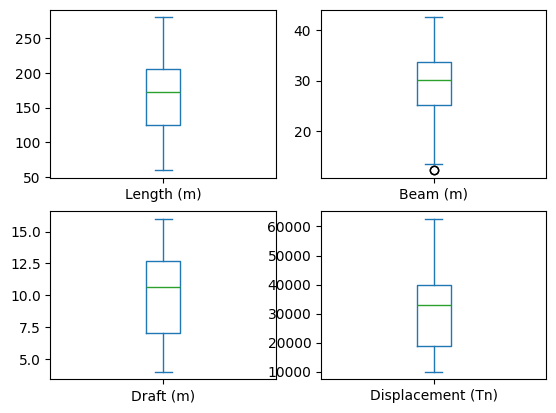

In [ ]:
# box and whisker plots
pd.DataFrame(data).plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

---
**Univariate Plots: histogram**

---

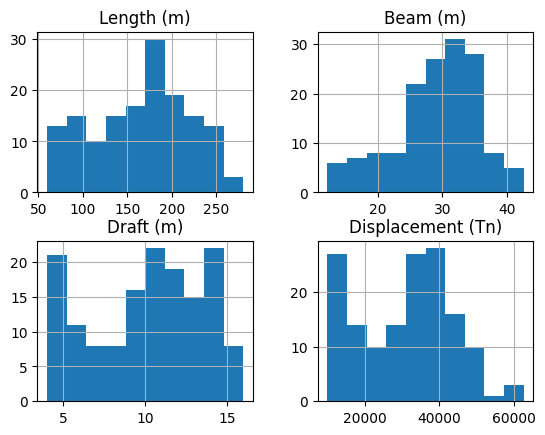

In [ ]:
# histograms
pd.DataFrame(data).hist()
plt.show()

It looks like perhaps two of the input variables have a Gaussian distribution. This is useful
to note as we can use algorithms that can exploit this assumption.

---
**Multivariate Plots: scatter plot**

---

Now we can look at the interactions between the variables. Let’s look at scatter plots of all
pairs of attributes. This can be helpful to spot structured relationships between input variables.

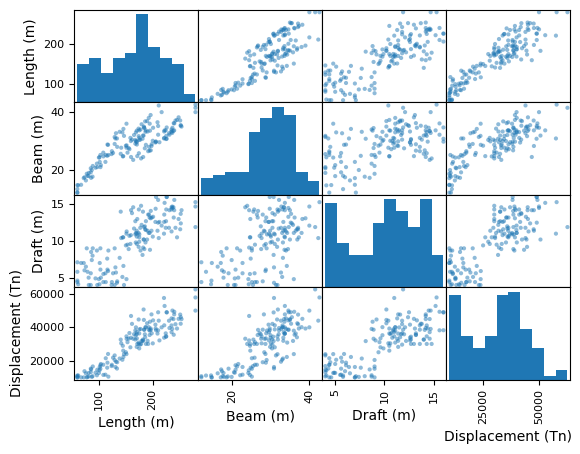

In [ ]:
# scatter plot matrix
scatter_matrix(pd.DataFrame(data))
plt.show()

Note the diagonal grouping of some pairs of attributes. This suggests a high correlation and
a predictable relationship.

## Evaluate Some Algorithms

Now it is time to create some models of the data and estimate their accuracy on unseen data.
Here is what we are going to cover in this step:
1. Separate out a validation dataset.
2. Setup the test harness to use 10-fold cross validation.
3. Build 5 different models to predict classes of vessels
4. Select the best model.

### Create a Validation Dataset

We need to know whether or not the model that we created is any good. Later, we will use
statistical methods to estimate the accuracy of the models that we create on unseen data.
We also want a more concrete estimate of the accuracy of the best model on unseen data by
evaluating it on actual unseen data. That is, we are going to hold back some data that the
algorithms will not get to see and we will use this data to get a second and independent idea of how accurate the best model might actually be. We will split the loaded dataset into two, 80%
of which we will use to train our models and 20% that we will hold back as a validation dataset.

---
**Split-out validation dataset**

---

In [ ]:
# Split-out validation dataset
array = pd.DataFrame(data).values
X = array[:,0:4]
Y = array[:,4]
validation_size = 0.20
seed = 7
X_train, X_validation, Y_train, Y_validation = train_test_split(X, Y,
test_size=validation_size, random_state=seed)

You now have training data in the `X train` and `Y train` for preparing models and a
`X validation` and `Y validation` sets that we can use later.

### Baseline Evaluation Test

We will use 10-fold cross validation to estimate accuracy. This will split our dataset into 10
parts, train on 9 and test on 1 and repeat for all combinations of train-test splits. We are using
the metric of accuracy to evaluate models. This is a ratio of the number of correctly predicted
instances divided by the total number of instances in the dataset multiplied by 100 to give a
percentage (e.g. 95% accurate). We will be using the scoring variable when we run build and
evaluate each model next.

---
**Test options and evaluation metric**

---

In [ ]:
# Test options and evaluation metric
num_folds = 10
seed = 7
scoring = 'accuracy'

### Build Models

We don’t know which algorithms would be good on this problem or what configurations to use.
We get an idea from the plots that some of the classes are partially linearly separable in some
dimensions, so we are expecting generally good results. Let’s evaluate six different algorithms:
- Logistic Regression (LR).
- Linear Discriminant Analysis (LDA).
- k-Nearest Neighbors (KNN).
- Classification and Regression Trees (CART).
- Gaussian Naive Bayes (NB).
- Support Vector Machines (SVM).

This list is a good mixture of simple linear (LR and LDA), nonlinear (KNN, CART, NB
and SVM) algorithms. We reset the random number seed before each run to ensure that the
evaluation of each algorithm is performed using exactly the same data splits. It ensures the
results are directly comparable. Let’s build and evaluate our five models:

---
**Spot-Check Algorithms**

---

In [ ]:
# Spot-Check Algorithms
models = []
models.append(('LR', LogisticRegression(max_iter=100000)))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('CART', DecisionTreeClassifier()))
models.append(('NB', GaussianNB()))
models.append(('SVM', SVC()))


---
**Evaluate each model in turn**

---

In [ ]:
# evaluate each model in turn
results = []
names = []
for name, model in models:
  kfold = KFold(n_splits=num_folds, random_state=seed, shuffle=True)
  cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring=scoring)
  results.append(cv_results)
  names.append(name)
  msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
  print(msg)

LR: 0.975000 (0.053359)
LDA: 0.991667 (0.025000)
KNN: 0.641667 (0.129368)
CART: 0.941667 (0.091667)
NB: 0.908333 (0.094648)
SVM: 0.700000 (0.145297)


We now have 6 models and accuracy estimations for each. We need to compare the models to
each other and select the most accurate. Running the example above, we get the following raw
results.


### **Model Performance Analysis**

1. **Top Performers**:
   - **LDA (Linear Discriminant Analysis)**:  
     **0.9917 accuracy (±0.025)**  
     Outstanding performance with near-perfect accuracy and the lowest variance (most stable). Likely the best choice for deployment if assumptions (Gaussian-distributed features, linear decision boundaries) hold.

   - **LR (Logistic Regression)**:  
     **0.9750 accuracy (±0.0534)**  
     Strong performance with moderate variance. Slightly worse than LDA but still excellent. Ideal if interpretability is needed (coefficients provide feature importance).

2. **Mid-Tier Models**:
   - **CART (Decision Tree)**:  
     **0.9417 accuracy (±0.0917)**  
     Decent accuracy but higher variance (risk of overfitting). Prone to instability with small data changes. Use with pruning/ensemble methods (e.g., Random Forest).

   - **NB (Naive Bayes)**:  
     **0.9083 accuracy (±0.0946)**  
     Respectable performance given its simplicity. High variance suggests sensitivity to feature dependencies (violates "naive" assumption). Good for baseline comparisons.

3. **Underperformers**:
   - **SVM (Support Vector Machine)**:  
     **0.7000 accuracy (±0.1453)**  
     Poor results likely due to:  
     - Suboptimal kernel (try RBF/poly tuning)  
     - Sensitive to feature scaling (did you standardize data?)  
     - Small dataset or class overlap.

   - **KNN (k-Nearest Neighbors)**:  
     **0.6417 accuracy (±0.1294)**  
     Worst performer. Potential issues:  
     - Incorrect `k` value (try grid search)  
     - Unscaled features (distance-based models need normalization)  
     - Noisy data or irrelevant features.

### **Key Observations**
- **LDA/LR Dominance**: Linear models excel, suggesting the problem has (mostly) linear separability.
- **High Variance in KNN/SVM**: Large standard deviations indicate sensitivity to data splits. Cross-validation is essential.
- **Non-linear Potential**: CART’s decent performance hints that some non-linearity exists, but not enough to justify its complexity over LDA.

### **Recommendations**
1. **Deploy LDA** if:  
   - Features are roughly Gaussian.  
   - Stability is critical (lowest std dev).  
   - You need fast inference.

2. **Try Ensemble Methods** (e.g., Random Forest, Gradient Boosting):  
   - May capture non-linearity better than CART alone.  
   - Likely to outperform KNN/SVM.

3. **Debug KNN/SVM**:  
   - Scale features (use `StandardScaler`).  
   - For SVM: Tune kernel (`rbf`/`poly`) and `C` parameter.  
   - For KNN: Optimize `k` and weights (e.g., distance-based).

4. **Feature Engineering**:  
   - If LDA/LR are already excellent, focus on interpretability.  
   - If pushing for 100% accuracy, explore interaction terms or non-linear features.



We can also
create a plot of the model evaluation results and compare the spread and the mean accuracy
of each model. There is a population of accuracy measures for each algorithm because each
algorithm was evaluated 10 times (10 fold cross validation).

---
**Compare Algorithms**

---

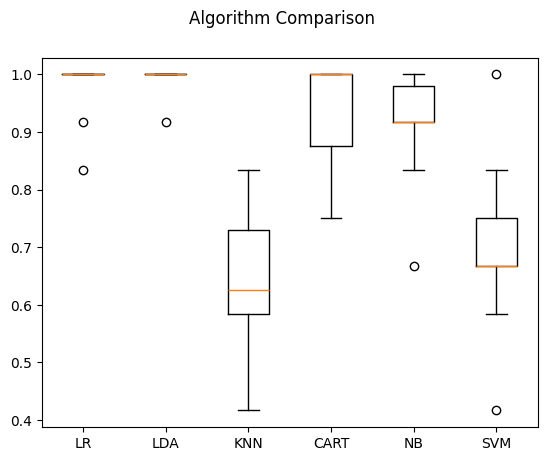

In [ ]:
# Compare Algorithms
fig = plt.figure()
fig.suptitle('Algorithm Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

You can see that the box and whisker plots are squashed at the top of the range, with many
samples achieving 100% accuracy.

### **Performance Breakdown**  
**1. Top Performers ( > 0.9 Accuracy)**  
- **LDA (Linear Discriminant Analysis)**  
  - Highest accuracy (near 1.0)  
  - Ideal for linearly separable data with Gaussian features.  
  - Low variance → Most stable model.  

- **LR (Logistic Regression)**  
  - Close second (~0.97)  
  - Prefer over LDA if interpretability (coefficients) is needed.  

**2. Mid-Range (0.8–0.9 Accuracy)**  
- **CART (Decision Tree)**  
  - ~0.94 accuracy but higher variance.  
  - Prone to overfitting; consider pruning or ensembles (e.g., Random Forest).  

- **NB (Naive Bayes)**  
  - ~0.91 accuracy.  
  - High variance suggests violated "naive" assumptions (feature independence).  

**3. Underperformers ( < 0.7 Accuracy)**  
- **SVM (Support Vector Machine)**  
  - Poor performance (~0.70). Likely due to:  
    - Unscaled features (SVMs are distance-sensitive).  
    - Suboptimal kernel (try `rbf` or tune hyperparameters).  

- **KNN (k-Nearest Neighbors)**  
  - Worst performer (~0.64). Potential fixes:  
    - Normalize features.  
    - Optimize `k` (grid search).  
    - Remove irrelevant features.  



### **Key Insights**  
- **Linear Models Dominate**: LDA/LR excel → Data is likely linearly separable.  
- **Non-Linear Potential**: CART’s decent performance suggests minor non-linearity, but not enough to justify complexity over LDA.  
- **Avoid SVM/KNN** without tuning/feature engineering.  



### **Actionable Recommendations**  
1. **Deploy LDA** for production (best accuracy + stability).  
2. **Debug SVM/KNN**:  
   - Scale features (use `StandardScaler`).  
   - For SVM: Tune kernel and `C` parameter.  
   - For KNN: Test `k=3` to `k=10` with cross-validation.  
3. **Experiment Further**:  
   - Ensemble methods (Random Forest, XGBoost).  
   - Feature engineering (interaction terms, PCA).  



## Make Predictions

The LDA algorithm was the most accurate model that we tested. Now we want to get an idea
of the accuracy of the model on our validation dataset. This will give us an independent final
check on the accuracy of the best model. It is important to keep a validation set just in case
you made a slip during training, such as overfitting to the training set or a data leak. Both
will result in an overly optimistic result. We can run the LDA model directly on the validation
set and summarize the results as a final accuracy score, a confusion matrix and a classification
report.

---
**Make predictions**

---

In [ ]:
# Initialize and train LDA model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, Y_train)  # Use your actual training data variables

# Make predictions on validation set
predictions = lda.predict(X_validation)

# Evaluate performance
print("Validation Accuracy: %.4f" % accuracy_score(Y_validation, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(Y_validation, predictions))
print("\nClassification Report:")
print(classification_report(Y_validation, predictions))

# Additional useful outputs for LDA
print("\nClass Priors:", lda.priors_)  # Class distribution in training
print("Feature Coefficients:\n", lda.coef_)  # Weight of each feature per class

Validation Accuracy: 1.0000

Confusion Matrix:
[[ 7  0  0]
 [ 0 12  0]
 [ 0  0 11]]

Classification Report:
                 precision    recall  f1-score   support

   Bulk Carrier       1.00      1.00      1.00         7
 Container Ship       1.00      1.00      1.00        12
Offshore Vessel       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30


Class Priors: [0.35833333 0.31666667 0.325     ]
Feature Coefficients:
 [[-7.54854825e-02  3.68463183e-01  2.84175790e-01  1.43062590e-04]
 [ 5.05225584e-01 -2.37070355e+00  1.22447967e+00  1.15878954e-04]
 [-4.09043498e-01  1.90366200e+00 -1.50640478e+00 -2.70643375e-04]]


We can see that the accuracy is 1.0 or 100%. The confusion matrix provides an indication of
the three errors made. Finally the classification report provides a breakdown of each class by precision, recall, f1-score and support showing excellent results (granted the validation dataset
was small).

If for example, we would have chosen KNN, then

In [ ]:
# Initialize and train KNN model
knn = KNeighborsClassifier()
knn.fit(X_train, Y_train)  # Use your actual training data variables

# Make predictions on validation set
predictions = knn.predict(X_validation)

# Evaluate performance
print("Validation Accuracy: %.4f" % accuracy_score(Y_validation, predictions))
print("\nConfusion Matrix:")
print(confusion_matrix(Y_validation, predictions))
print("\nClassification Report:")
print(classification_report(Y_validation, predictions))


Validation Accuracy: 0.8333

Confusion Matrix:
[[ 4  3  0]
 [ 2 10  0]
 [ 0  0 11]]

Classification Report:
                 precision    recall  f1-score   support

   Bulk Carrier       0.67      0.57      0.62         7
 Container Ship       0.77      0.83      0.80        12
Offshore Vessel       1.00      1.00      1.00        11

       accuracy                           0.83        30
      macro avg       0.81      0.80      0.81        30
   weighted avg       0.83      0.83      0.83        30



The confusion matrix provides an indication of several errors (5) made.

In [ ]:
import numpy as np
import pandas as pd

# Configuration
np.random.seed(42)  # For reproducibility
num_samples = 150   # Same as Iris dataset
filename = 'Naval_Dataset.csv'

# Vessel classes
vessel_types = ['Cargo Ship', 'Passenger Ship', 'Fishing Vessel']

# Generate synthetic data
data = []

for i in range(num_samples):
    vessel_class = i // 50  # 0, 1, or 2 (50 samples per class)

    if vessel_class == 0:  # Cargo Ship
        length = np.random.normal(200, 30)
        beam = np.random.normal(32, 4)
        draft = np.random.normal(12, 1.5)
        displacement = np.random.normal(50000, 10000)

    elif vessel_class == 1:  # Passenger Ship
        length = np.random.normal(150, 20)
        beam = np.random.normal(25, 3)
        draft = np.random.normal(8, 1)
        displacement = np.random.normal(20000, 5000)

    else:  # Fishing Vessel
        length = np.random.normal(30, 5)
        beam = np.random.normal(7, 1)
        draft = np.random.normal(3.5, 0.5)
        displacement = np.random.normal(500, 100)

    # Ensure realistic values (similar to Iris dataset constraints)
    length = max(20, min(300, length))
    beam = max(5, min(40, beam))
    draft = max(2, min(15, draft))
    displacement = max(100, min(70000, displacement))

    # Format with same decimal precision as Iris dataset
    data.append([
        round(length, 1),    # 1 decimal like sepal length
        round(beam, 1),       # 1 decimal like sepal width
        round(draft, 1),      # 1 decimal like petal length
        round(displacement),  # 0 decimals like petal width (which was stored as float with .0)
        vessel_types[vessel_class]
    ])

# Create DataFrame (without column names)
df = pd.DataFrame(data)

# Save to CSV without header
df.to_csv(filename, header=False, index=False)

print(f"Naval dataset generated and saved as '{filename}'")
print("Sample data:")
print(df.head())
print("\nClass distribution:")
print(df[4].value_counts())

Naval dataset generated and saved as 'Naval_Dataset.csv'
Sample data:
       0     1     2      3           4
0  214.9  31.4  13.0  65230  Cargo Ship
1  193.0  31.1  14.4  57674  Cargo Ship
2  185.9  34.2  11.3  45343  Cargo Ship
3  207.3  24.3   9.4  44377  Cargo Ship
4  169.6  33.3  10.6  35877  Cargo Ship

Class distribution:
4
Cargo Ship        50
Passenger Ship    50
Fishing Vessel    50
Name: count, dtype: int64


In [ ]:
# To load without column names
df = pd.read_csv('Naval_Dataset.csv', header=None)

# To load with column names (if you want to add them later)
columns = ['Length (m)','Beam (m)','Draft (m)','Displacement (Tn)','Vessel Type']
df = pd.read_csv('Naval_Dataset.csv', header=None, names=columns)

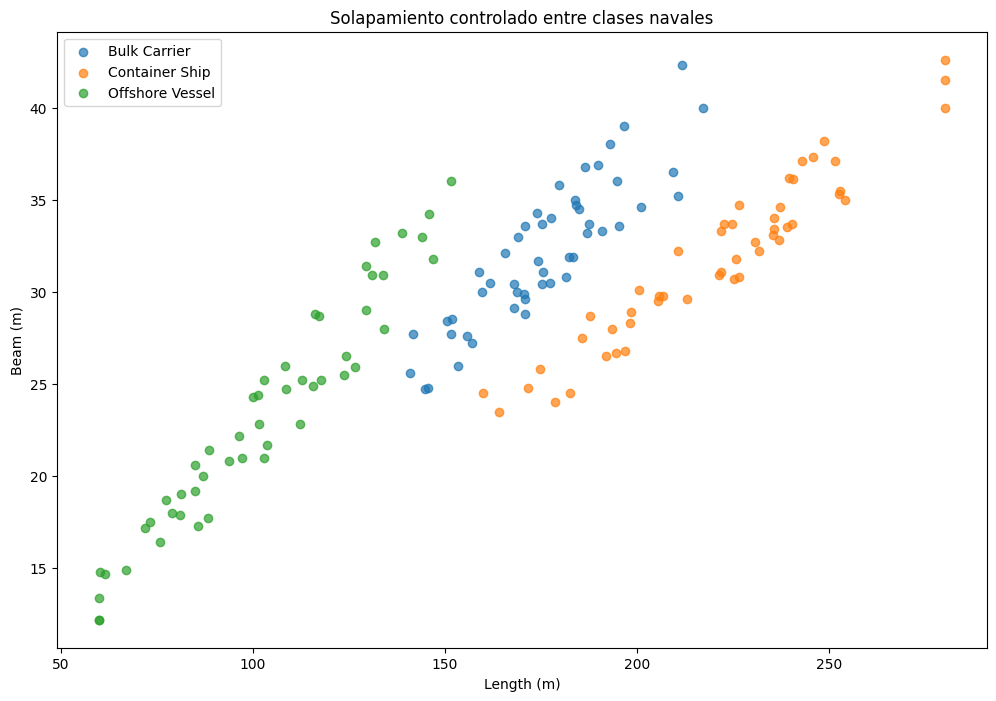

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
num_samples = 150
filename = 'Naval_Dataset3.csv'

vessel_types = ['Bulk Carrier', 'Container Ship', 'Offshore Vessel']
data = []

# Bulk Carrier (50 samples) - Solapa con Container Ship en tamaño grande
length = np.clip(np.random.normal(180, 20, 50), 140, 220)
beam = length / np.random.uniform(5.0, 6.0, 50)  # Más anchos
draft = np.clip(np.random.normal(11, 1.5, 50), 8, 14)
displacement = np.clip(300 + 200*length + np.random.normal(0, 5000, 50), 25000, 60000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[0]]*50))

# Container Ship (50 samples) - Solapa con ambos extremos
length = np.clip(np.random.normal(220, 30, 50), 160, 280)  # Más largos
beam = length / np.random.uniform(6.5, 7.5, 50)  # Más estrechos
draft = np.clip(np.random.normal(13, 2, 50), 9, 16)
displacement = np.clip(400 + 180*length + np.random.normal(0, 8000, 50), 30000, 70000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[1]]*50))

# Offshore Vessel (50 samples) - Solapa con Bulk Carrier en tamaño mediano
length = np.clip(np.random.normal(100, 25, 50), 60, 160)
beam = length / np.random.uniform(4.0, 5.0, 50)  # Formas más robustas
draft = np.clip(np.random.normal(6, 1.8, 50), 4, 9)
displacement = np.clip(200 + 150*length + np.random.normal(0, 3000, 50), 10000, 30000)
data.extend(zip(length.round(1), beam.round(1), draft.round(1), displacement.round(0),
            [vessel_types[2]]*50))

df = pd.DataFrame(data)
df.to_csv(filename, header=False, index=False)

# Visualización del solapamiento
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
for i, vessel in enumerate(vessel_types):
    subset = df[df[4] == vessel]
    plt.scatter(subset[0], subset[1], label=vessel, alpha=0.7)
plt.xlabel('Length (m)')
plt.ylabel('Beam (m)')
plt.title('Solapamiento controlado entre clases navales')
plt.legend()
plt.show()

Optimized Global Statistics:
            0       1       2         3
count  150.00  150.00  150.00    150.00
mean   166.19   29.06   10.08  30565.24
std     54.73    6.45    3.47  12665.51
min     60.00   12.20    4.00  10000.00
25%    124.85   25.20    7.02  18670.25
50%    172.80   30.05   10.65  32725.00
75%    205.70   33.68   12.70  39452.75
max    280.00   42.60   16.00  62203.00


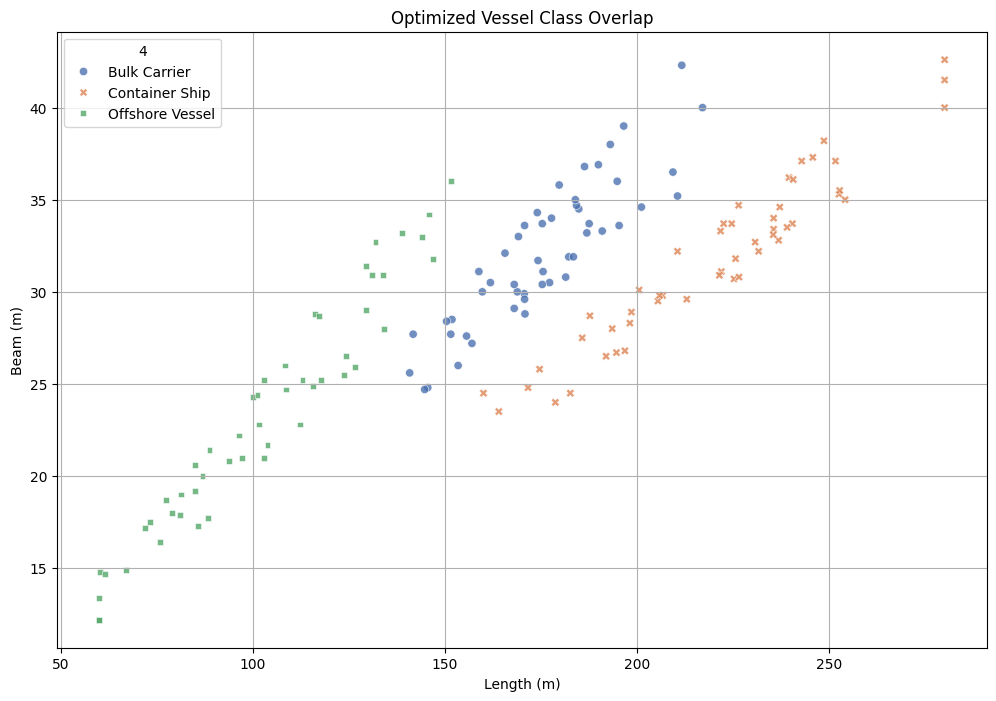

In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
num_samples = 150
filename = 'Naval_Dataset_Optimized.csv'

vessel_types = ['Bulk Carrier', 'Container Ship', 'Offshore Vessel']
data = []

# Parámetros optimizados para solapamiento controlado
params = {
    'Bulk Carrier': {
        'length': (180, 20, 140, 220),
        'beam_ratio': (5.0, 6.0),
        'draft': (11, 1.5, 8, 14),
        'disp_factor': (200, 5000, 25000, 60000)
    },
    'Container Ship': {
        'length': (220, 30, 160, 280),
        'beam_ratio': (6.5, 7.5),
        'draft': (13, 2, 9, 16),
        'disp_factor': (180, 8000, 30000, 70000)
    },
    'Offshore Vessel': {
        'length': (100, 25, 60, 160),
        'beam_ratio': (4.0, 5.0),
        'draft': (6, 1.8, 4, 9),
        'disp_factor': (150, 3000, 10000, 30000)
    }
}

for vessel in vessel_types:
    p = params[vessel]
    length = np.clip(np.random.normal(p['length'][0], p['length'][1], 50), p['length'][2], p['length'][3])
    beam = length / np.random.uniform(p['beam_ratio'][0], p['beam_ratio'][1], 50)
    draft = np.clip(np.random.normal(p['draft'][0], p['draft'][1], 50), p['draft'][2], p['draft'][3])
    displacement = np.clip(
        p['disp_factor'][0] * length + np.random.normal(0, p['disp_factor'][1], 50),
        p['disp_factor'][2], p['disp_factor'][3]
    )
    data.extend(zip(
        length.round(1),
        beam.round(1),
        draft.round(1),
        displacement.round(0),
        [vessel]*50
    ))

df = pd.DataFrame(data)
df.to_csv(filename, header=False, index=False)

# Estadísticas globales mejoradas
print("Optimized Global Statistics:")
print(df.iloc[:, :4].describe().round(2))

# Visualización de solapamiento
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x=0, y=1, hue=4, style=4, palette="deep", alpha=0.8)
plt.xlabel('Length (m)')
plt.ylabel('Beam (m)')
plt.title('Optimized Vessel Class Overlap')
plt.grid(True)
plt.show()

---

## HOMEWORK: Machine Learning Project - Vessel Classification
---

In [ ]:
# HOMEWORK: Machine Learning Project - Vessel Classification
# COMPLETE THE FOLLOWING TASKS BASED ON WHAT YOU LEARNED IN THE NOTEBOOK




# =============================================================================
# TASK 1: Data Exploration and Analysis
# =============================================================================

print("TASK 1: Data Exploration and Analysis")
print("=" * 50)

# 1. Display basic information about the dataset
print("1. Dataset shape:")
# YOUR CODE HERE (show rows and columns)

# 2. Show statistical summary for numerical columns only
print("\n2. Statistical summary:")
# YOUR CODE HERE

# 3. Check for missing values in the dataset
print("\n3. Missing values:")
# YOUR CODE HERE

# 4. Find which vessel type has the highest average beam (width)
print("\n4. Vessel type with highest average beam:")
beam_by_type = None  # YOUR CODE HERE (group by vessel type and calculate mean beam)
highest_beam_type = None  # YOUR CODE HERE
print(f"Vessel type with highest average beam: {highest_beam_type}")

# =============================================================================
# TASK 2: Data Visualization
# =============================================================================

print("\n" + "=" * 50)
print("TASK 2: Data Visualization")
print("=" * 50)

import matplotlib.pyplot as plt

# 1. Create a boxplot for draft by vessel type
print("1. Creating boxplot for draft by vessel type...")
plt.figure(figsize=(12, 6))
# YOUR CODE HERE (create boxplot)
plt.title('Draft Distribution by Vessel Type')
plt.ylabel('Draft (m)')
plt.show()

# 2. Create scatter plot: Length vs Displacement, colored by vessel type
print("\n2. Creating scatter plot: Length vs Displacement...")
plt.figure(figsize=(12, 6))
# YOUR CODE HERE (create scatter plot)
plt.title('Length vs Displacement by Vessel Type')
plt.xlabel('Length (m)')
plt.ylabel('Displacement (Tn)')
plt.legend()
plt.show()

# =============================================================================
# TASK 3: Data Preprocessing
# =============================================================================

print("\n" + "=" * 50)
print("TASK 3: Data Preprocessing")
print("=" * 50)

# 1. Separate features (X) and target variable (y)
print("1. Separating features and target variable...")
X = None  # YOUR CODE HERE (numerical features only)
y = None  # YOUR CODE HERE ('Vessel Type' column)

# 2. Split data into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split

print("2. Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = None  # YOUR CODE HERE

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# =============================================================================
# TASK 4: Model Training
# =============================================================================

print("\n" + "=" * 50)
print("TASK 4: Model Training")
print("=" * 50)

# Train multiple classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {}

print("Training models...")

# 1. Train a Logistic Regression model
print("1. Training Logistic Regression...")
lr_model = None  # YOUR CODE HERE
models['Logistic Regression'] = lr_model

# 2. Train a K-Nearest Neighbors model with k=5
print("2. Training K-Nearest Neighbors...")
knn_model = None  # YOUR CODE HERE
models['K-Nearest Neighbors'] = knn_model

# 3. Train a Decision Tree model
print("3. Training Decision Tree...")
dt_model = None  # YOUR CODE HERE
models['Decision Tree'] = dt_model

# 4. Train a Support Vector Machine model
print("4. Training Support Vector Machine...")
svm_model = None  # YOUR CODE HERE
models['Support Vector Machine'] = svm_model

print("All models trained successfully!")

# =============================================================================
# TASK 5: Model Evaluation
# =============================================================================

print("\n" + "=" * 50)
print("TASK 5: Model Evaluation")
print("=" * 50)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

print("Evaluating models on test data:")

for name, model in models.items():
    # Make predictions
    y_pred = None  # YOUR CODE HERE

    # Calculate accuracy
    accuracy = None  # YOUR CODE HERE

    results[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")

# Show detailed classification report for one model
print("\nDetailed classification report for Decision Tree:")
# YOUR CODE HERE (show classification report for one model)

# =============================================================================
# TASK 6: Cross-Validation
# =============================================================================

print("\n" + "=" * 50)
print("TASK 6: Cross-Validation")
print("=" * 50)

from sklearn.model_selection import cross_val_score

print("Performing 5-fold cross validation:")

for name, model in models.items():
    # Perform 5-fold cross validation
    cv_scores = None  # YOUR CODE HERE

    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# =============================================================================
# TASK 7: Feature Importance Analysis
# =============================================================================

print("\n" + "=" * 50)
print("TASK 7: Feature Importance Analysis")
print("=" * 50)

# Check if models have feature_importance_ attribute (like Decision Tree)
print("Analyzing feature importance...")

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        print(f"\nFeature Importance - {name}:")
        features = ['Length (m)', 'Beam (m)', 'Draft (m)', 'Displacement (Tn)']
        importance = model.feature_importances_

        for feature, imp in zip(features, importance):
            print(f"  {feature}: {imp:.4f}")

# =============================================================================
# TASK 8: Analysis Questions
# =============================================================================

print("\n" + "=" * 50)
print("TASK 8: Analysis Questions")
print("=" * 50)

print("Please answer the following questions based on your results:")
print("\n1. Which model performed best and why do you think it was the most effective?")
print("2. What are the most important features for classifying vessels according to your analysis?")
print("3. How could you potentially improve the model performance?")
print("4. Based on the feature importance, what physical characteristics most distinguish vessel types?")
print("5. Why is cross-validation important in evaluating machine learning models?")

print("\n" + "=" * 50)
print("HOMEWORK COMPLETED!")
print("=" * 50)

In [ ]:
# HOMEWORK: Machine Learning Project - Vessel Classification
# COMPLETE THE FOLLOWING TASKS BASED ON WHAT YOU LEARNED IN THE NOTEBOOK

# =============================================================================
# TASK 0: Data Loading
# =============================================================================

print("TASK 0: Data Loading")
print("=" * 50)

# Load the necessary libraries
print("1. Loading libraries...")
# YOUR CODE HERE (import necessary libraries)

# Load the dataset
print("2. Loading dataset...")
# YOUR CODE HERE (load the Naval_Dataset3.csv file)

# Display the first 10 rows of the dataset
print("3. First 10 rows of the dataset:")
# YOUR CODE HERE (show first 10 rows)

print("Dataset loaded successfully!")

# =============================================================================
# TASK 1: Data Exploration and Analysis
# =============================================================================

print("TASK 1: Data Exploration and Analysis")
print("=" * 50)

# 1. Display basic information about the dataset
print("1. Dataset shape:")
# YOUR CODE HERE (show rows and columns)

# 2. Show statistical summary for numerical columns only
print("\n2. Statistical summary:")
# YOUR CODE HERE

# 3. Check for missing values in the dataset
print("\n3. Missing values:")
# YOUR CODE HERE

# 4. Find which vessel type has the highest average beam (width)
print("\n4. Vessel type with highest average beam:")
beam_by_type = None  # YOUR CODE HERE (group by vessel type and calculate mean beam)
highest_beam_type = None  # YOUR CODE HERE
print(f"Vessel type with highest average beam: {highest_beam_type}")

# =============================================================================
# TASK 2: Data Visualization
# =============================================================================

print("\n" + "=" * 50)
print("TASK 2: Data Visualization")
print("=" * 50)

import matplotlib.pyplot as plt

# 1. Create a boxplot for draft by vessel type
print("1. Creating boxplot for draft by vessel type...")
plt.figure(figsize=(12, 6))
# YOUR CODE HERE (create boxplot)
plt.title('Draft Distribution by Vessel Type')
plt.ylabel('Draft (m)')
plt.show()

# 2. Create scatter plot: Length vs Displacement, colored by vessel type
print("\n2. Creating scatter plot: Length vs Displacement...")
plt.figure(figsize=(12, 6))
# YOUR CODE HERE (create scatter plot)
plt.title('Length vs Displacement by Vessel Type')
plt.xlabel('Length (m)')
plt.ylabel('Displacement (Tn)')
plt.legend()
plt.show()

# =============================================================================
# TASK 3: Data Preprocessing
# =============================================================================

print("\n" + "=" * 50)
print("TASK 3: Data Preprocessing")
print("=" * 50)

# 1. Separate features (X) and target variable (y)
print("1. Separating features and target variable...")
X = None  # YOUR CODE HERE (numerical features only)
y = None  # YOUR CODE HERE ('Vessel Type' column)

# 2. Split data into training (80%) and testing (20%) sets
from sklearn.model_selection import train_test_split

print("2. Splitting data into training and testing sets...")
X_train, X_test, y_train, y_test = None  # YOUR CODE HERE

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

# =============================================================================
# TASK 4: Model Training
# =============================================================================

print("\n" + "=" * 50)
print("TASK 4: Model Training")
print("=" * 50)

# Train multiple classification models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

models = {}

print("Training models...")

# 1. Train a Logistic Regression model
print("1. Training Logistic Regression...")
lr_model = None  # YOUR CODE HERE
models['Logistic Regression'] = lr_model

# 2. Train a K-Nearest Neighbors model with k=5
print("2. Training K-Nearest Neighbors...")
knn_model = None  # YOUR CODE HERE
models['K-Nearest Neighbors'] = knn_model

# 3. Train a Decision Tree model
print("3. Training Decision Tree...")
dt_model = None  # YOUR CODE HERE
models['Decision Tree'] = dt_model

# 4. Train a Support Vector Machine model
print("4. Training Support Vector Machine...")
svm_model = None  # YOUR CODE HERE
models['Support Vector Machine'] = svm_model

print("All models trained successfully!")

# =============================================================================
# TASK 5: Model Evaluation
# =============================================================================

print("\n" + "=" * 50)
print("TASK 5: Model Evaluation")
print("=" * 50)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

results = {}

print("Evaluating models on test data:")

for name, model in models.items():
    # Make predictions
    y_pred = None  # YOUR CODE HERE

    # Calculate accuracy
    accuracy = None  # YOUR CODE HERE

    results[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")

# Show detailed classification report for one model
print("\nDetailed classification report for Decision Tree:")
# YOUR CODE HERE (show classification report for one model)

# =============================================================================
# TASK 6: Cross-Validation
# =============================================================================

print("\n" + "=" * 50)
print("TASK 6: Cross-Validation")
print("=" * 50)

from sklearn.model_selection import cross_val_score

print("Performing 5-fold cross validation:")

for name, model in models.items():
    # Perform 5-fold cross validation
    cv_scores = None  # YOUR CODE HERE

    print(f"{name}: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# =============================================================================
# TASK 7: Feature Importance Analysis
# =============================================================================

print("\n" + "=" * 50)
print("TASK 7: Feature Importance Analysis")
print("=" * 50)

# Check if models have feature_importance_ attribute (like Decision Tree)
print("Analyzing feature importance...")

for name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        print(f"\nFeature Importance - {name}:")
        features = ['Length (m)', 'Beam (m)', 'Draft (m)', 'Displacement (Tn)']
        importance = model.feature_importances_

        for feature, imp in zip(features, importance):
            print(f"  {feature}: {imp:.4f}")

# =============================================================================
# TASK 8: Analysis Questions
# =============================================================================

print("\n" + "=" * 50)
print("TASK 8: Analysis Questions")
print("=" * 50)

print("Please answer the following questions based on your results:")
print("\n1. Which model performed best and why do you think it was the most effective?")
print("2. What are the most important features for classifying vessels according to your analysis?")
print("3. How could you potentially improve the model performance?")
print("4. Based on the feature importance, what physical characteristics most distinguish vessel types?")
print("5. Why is cross-validation important in evaluating machine learning models?")

print("\n" + "=" * 50)
print("HOMEWORK COMPLETED!")
print("=" * 50)